In [41]:
!pip install arch
import os
# Полное подавление вывода stderr (предупреждения из C-расширений)
sys.stderr = open(os.devnull, 'w')
import warnings
warnings.filterwarnings('ignore')
import sys
if not sys.warnoptions:
    warnings.simplefilter('ignore')
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from scipy import stats
from scipy.stats import probplot
from statsmodels.stats.diagnostic import het_arch
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox
from arch import arch_model

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

def mse(y_true, y_pred):
    """Среднеквадратичная ошибка (MSE)"""
    return np.mean((np.array(y_true) - np.array(y_pred)) ** 2)

def rmse(y_true, y_pred):
    """Корень из среднеквадратичной ошибки (RMSE)"""
    return np.sqrt(mse(y_true, y_pred))

def mae(y_true, y_pred):
    """Средняя абсолютная ошибка (MAE)"""
    return np.mean(np.abs(np.array(y_true) - np.array(y_pred)))

print("Все библиотеки импортированы")

Все библиотеки импортированы


In [42]:
# Загрузка данных
data = yf.download(['BTC-USD', '^GSPC'], start='2018-01-01', end='2025-12-31')
prices = data['Close'].dropna()

# Логарифмические доходности
returns_raw = np.log(prices / prices.shift(1))
returns = returns_raw  # для моделей

print(f"Период данных: {returns.index[0].strftime('%Y-%m-%d')} — {returns.index[-1].strftime('%Y-%m-%d')}")
print(f"Всего наблюдений: {len(returns)}")

# Разделение на обучающую и тестовую выборки (80/20)
split_point = int(len(returns) * 0.8)
train_data = returns.iloc[:split_point]
test_data  = returns.iloc[split_point:]

print(f"\nОбучающая выборка: {len(train_data)} наблюдений "
      f"({train_data.index[0].date()} — {train_data.index[-1].date()})")
print(f"Тестовая выборка:  {len(test_data)} наблюдений "
      f"({test_data.index[0].date()} — {test_data.index[-1].date()})")

btc_train   = train_data['BTC-USD']
btc_test    = test_data['BTC-USD']
sp500_train = train_data['^GSPC']
sp500_test  = test_data['^GSPC']


Период данных: 2018-01-02 — 2025-12-30
Всего наблюдений: 2010

Обучающая выборка: 1608 наблюдений (2018-01-02 — 2024-05-22)
Тестовая выборка:  402 наблюдений (2024-05-23 — 2025-12-30)


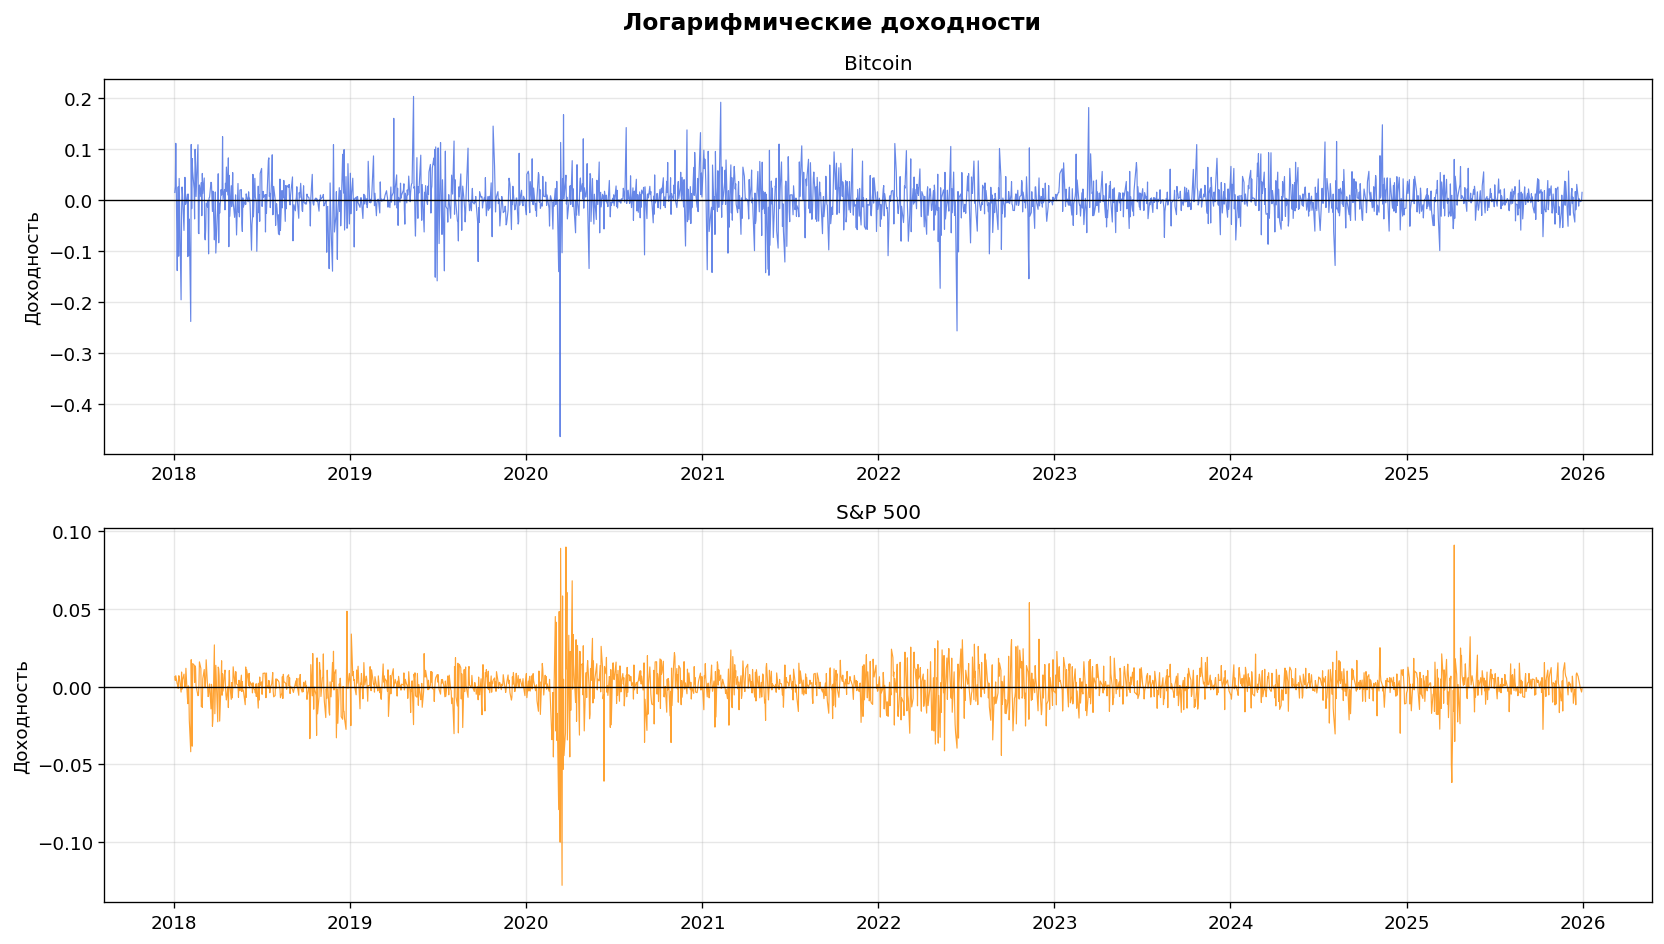

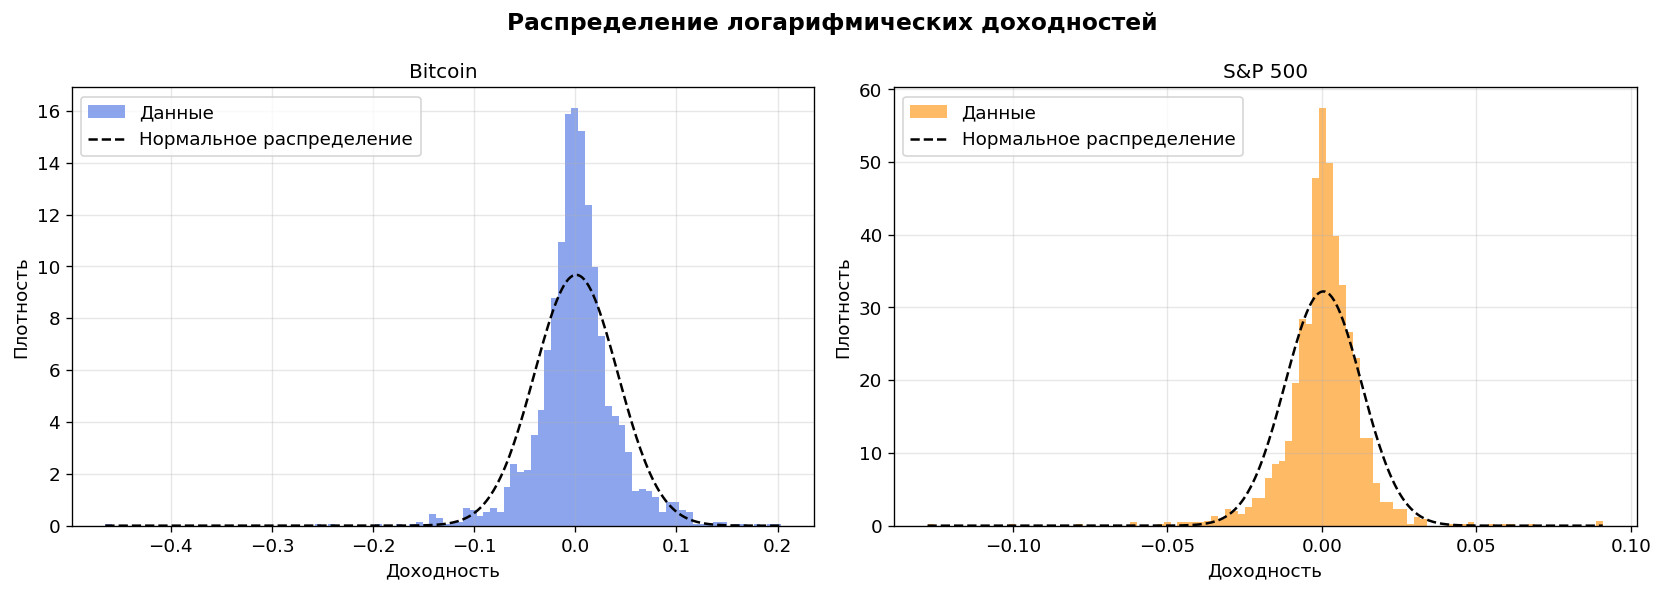

In [43]:
# Логарифмические доходности

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Логарифмические доходности', fontsize=14, fontweight='bold')

axes[0].plot(returns['BTC-USD'], color='royalblue', linewidth=0.7, alpha=0.8)
axes[0].set_title('Bitcoin', fontsize=12)
axes[0].set_ylabel('Доходность')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(returns['^GSPC'], color='darkorange', linewidth=0.7, alpha=0.8)
axes[1].set_title('S&P 500', fontsize=12)
axes[1].set_ylabel('Доходность')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Гистограммы доходностей с наложенной нормальной кривой
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Распределение логарифмических доходностей', fontsize=14, fontweight='bold')

for ax, series, label, color in zip(
        axes,
        [returns['BTC-USD'], returns['^GSPC']],
        ['Bitcoin', 'S&P 500'],
        ['royalblue', 'darkorange']):

    ax.hist(series, bins=100, density=True, color=color, alpha=0.6, label='Данные')

    # Нормальная кривая для сравнения
    x = np.linspace(series.min(), series.max(), 300)
    ax.plot(x, stats.norm.pdf(x, series.mean(), series.std()),
            'k--', linewidth=1.5, label='Нормальное распределение')

    ax.set_title(label, fontsize=12)
    ax.set_xlabel('Доходность')
    ax.set_ylabel('Плотность')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [44]:
print("ПРЕДВАРИТЕЛЬНЫЙ АНАЛИЗ (обучающая выборка)")
print("=" * 80)

rows = {}
for label, series in [('BTC-USD', btc_train), ('S&P 500', sp500_train)]:
    series_clean = series.dropna().replace([np.inf, -np.inf], np.nan).dropna()

    adf_stat, adf_p, *_ = adfuller(series_clean)
    jb_stat, jb_p = stats.jarque_bera(series_clean)[:2]

    rows[label] = {
        'Ст. откл. (%)': round(series_clean.std() * 100, 2), 
        'Годовая волатильность (%)': round(series_clean.std() * np.sqrt(252) * 100, 0),
        'Минимум (%)': round(series_clean.min() * 100, 2),
        'Максимум (%)': round(series_clean.max() * 100, 2),
        'Асимметрия': round(series_clean.skew(), 4),
        'Эксцесс': round(series_clean.kurtosis(), 4),
        'ADF p-value': round(adf_p, 4),
        'Стационарность': 'ДА' if adf_p < 0.05 else 'НЕТ',
        'JB p-value': round(jb_p, 4),
        'Нормальность': 'НЕТ' if jb_p < 0.05 else 'ДА',
    }

analysis_df = pd.DataFrame(rows).T
print(analysis_df.to_string())

ПРЕДВАРИТЕЛЬНЫЙ АНАЛИЗ (обучающая выборка)
        Ст. откл. (%) Годовая волатильность (%) Минимум (%) Максимум (%) Асимметрия  Эксцесс ADF p-value Стационарность JB p-value Нормальность
BTC-USD          4.38                      70.0      -46.47         20.3    -0.9877  10.9572         0.0             ДА        0.0          НЕТ
S&P 500          1.28                      20.0      -12.77         8.97     -0.807  14.2117         0.0             ДА        0.0          НЕТ


In [45]:
from statsmodels.stats.diagnostic import het_arch

NLAGS = 10
results_arch = {}

for label, series in [('S&P 500', sp500_train), ('Bitcoin', btc_train)]:
    # Очистка от inf/nan
    series_clean = series.dropna().replace([np.inf, -np.inf], np.nan).dropna()
    
    # het_arch требует, чтобы ряд был стационарным по среднему (вычтем среднее)
    resid = series_clean - series_clean.mean()
    
    lm_stat, lm_pval, f_stat, f_pval = het_arch(resid, nlags=NLAGS)
    results_arch[label] = {
        'LM-статистика (χ²)': round(lm_stat, 2),
        'p-значение': f'< 0.001' if lm_pval < 0.001 else round(lm_pval, 4),
        'Число лагов': NLAGS,
        'Вывод': 'ARCH-эффекты есть' if lm_pval < 0.05 else 'ARCH-эффекты не обнаружены',
    }
for label, res in results_arch.items():
    print(f"{label}: {res}")

S&P 500: {'LM-статистика (χ²)': np.float64(630.21), 'p-значение': '< 0.001', 'Число лагов': 10, 'Вывод': 'ARCH-эффекты есть'}
Bitcoin: {'LM-статистика (χ²)': np.float64(31.09), 'p-значение': '< 0.001', 'Число лагов': 10, 'Вывод': 'ARCH-эффекты есть'}


In [46]:
btc_train_clean = btc_train.dropna().values
sp500_train_clean = sp500_train.dropna()

def compare_garch_models(returns_series, name):
    """
    Оценивает четыре GARCH-спецификации и возвращает таблицу AIC/BIC.
    """
    # Очистка от NaN
    returns_clean = returns_series.dropna()
    
    specifications = [
        ('GARCH(1,1)',     {'p': 1, 'q': 1, 'vol': 'GARCH'}),
        ('GARCH(1,2)',     {'p': 1, 'q': 2, 'vol': 'GARCH'}),
        ('GARCH(2,1)',     {'p': 2, 'q': 1, 'vol': 'GARCH'}),
        ('GJR-GARCH(1,1)', {'p': 1, 'q': 1, 'vol': 'GARCH', 'o': 1}),
    ]

    results, models = [], {}
    print(f"\n{name} (n={len(returns_clean)}):")

    for spec_name, params in specifications:
        try:
            fitted = arch_model(
                returns_clean * 100,
                mean='Constant', 
                dist='t', 
                **params
            ).fit(update_freq=0, disp='off')

            models[spec_name] = fitted
            results.append({
                'model': spec_name,
                'aic': fitted.aic,
                'bic': fitted.bic,
                'log_likelihood': fitted.loglikelihood,
            })
            print(f"  {spec_name:<20} AIC = {fitted.aic:.2f}   BIC = {fitted.bic:.2f}")

        except Exception as exc:
            print(f"  {spec_name:<20} ошибка: {exc}")

    best = min(results, key=lambda r: r['aic'])
    print(f"Лучшая модель: {best['model']} (AIC = {best['aic']:.2f})")
    return results, models

btc_results,   btc_models   = compare_garch_models(btc_train,   'Bitcoin')
sp500_results, sp500_models = compare_garch_models(sp500_train, 'S&P 500')


Bitcoin (n=1607):
  GARCH(1,1)           AIC = 8776.84   BIC = 8803.75
  GARCH(1,2)           AIC = 8778.80   BIC = 8811.09
  GARCH(2,1)           AIC = 8778.84   BIC = 8811.13
  GJR-GARCH(1,1)       AIC = 8778.09   BIC = 8810.39
Лучшая модель: GARCH(1,1) (AIC = 8776.84)

S&P 500 (n=1607):
  GARCH(1,1)           AIC = 4454.88   BIC = 4481.79
  GARCH(1,2)           AIC = 4456.88   BIC = 4489.17
  GARCH(2,1)           AIC = 4455.06   BIC = 4487.35
  GJR-GARCH(1,1)       AIC = 4408.91   BIC = 4441.20
Лучшая модель: GJR-GARCH(1,1) (AIC = 4408.91)


In [47]:
print(btc_models['GARCH(1,1)'].summary())

print(sp500_models['GJR-GARCH(1,1)'].summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                      BTC-USD   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -4383.42
Distribution:      Standardized Student's t   AIC:                           8776.84
Method:                  Maximum Likelihood   BIC:                           8803.75
                                              No. Observations:                 1607
Date:                      Sun, May 03 2026   Df Residuals:                     1606
Time:                              12:35:12   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu     

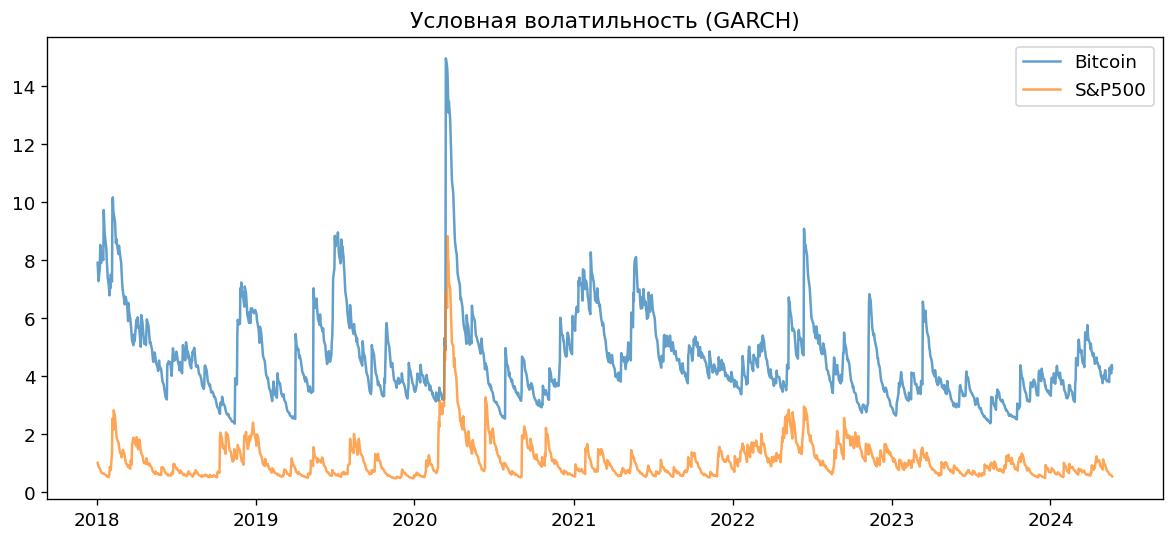

In [48]:
btc_vol = btc_models['GARCH(1,1)'].conditional_volatility
sp500_vol = sp500_models['GJR-GARCH(1,1)'].conditional_volatility

plt.figure(figsize=(12, 5))
plt.plot(btc_vol, label='Bitcoin', alpha=0.7)
plt.plot(sp500_vol, label='S&P500', alpha=0.7)
plt.title('Условная волатильность (GARCH)')
plt.legend()
plt.show()

In [ ]:
results = []

for model, name in [(btc_models['GARCH(1,1)'], 'Bitcoin'),
                    (sp500_models['GJR-GARCH(1,1)'], 'S&P 500')]:
    
    resid = model.std_resid.dropna()
    
    lb = acorr_ljungbox(resid, lags=[10, 20])
    lb_sq = acorr_ljungbox(resid**2, lags=[10, 20])
    arch_p = het_arch(resid, nlags=5)[1]
    jb_p = jarque_bera(resid)[1]
    
    results.append({
        'Актив': name,
        'LB (10), z': f"{lb['lb_pvalue'].iloc[0]:.3f}",
        'LB (20), z': f"{lb['lb_pvalue'].iloc[1]:.3f}",
        'LB (10), z²': f"{lb_sq['lb_pvalue'].iloc[0]:.3f}",
        'LB (20), z²': f"{lb_sq['lb_pvalue'].iloc[1]:.3f}",
        'ARCH-LM (5)': f"{arch_p:.3f}",
        'Jarque-Bera': f"{jb_p:.3f}"
    })

df_results = pd.DataFrame(results)
print("\nДиагностические тесты для стандартизованных остатков")
print(df_results.to_string(index=False))


Таблица 7. Диагностические тесты для стандартизованных остатков
  Актив LB (10), z LB (20), z LB (10), z² LB (20), z² ARCH-LM (5) Jarque-Bera
Bitcoin      0.178      0.235       0.088       0.370       0.018       0.000
S&P 500      0.319      0.437       0.829       0.960       0.581       0.000


In [50]:
def rolling_forecast_volatility(train_series, test_series,
                                 use_gjr=False, dist='t',
                                 verbose_step=50):
    forecast_list, actual_list = [], []
    errors = 0

    for i in range(len(test_series)):
        if verbose_step and i % verbose_step == 0:
            print(f"  Шаг {i}/{len(test_series)} ...")

        window = pd.concat([train_series, test_series.iloc[:i]]) if i > 0 else train_series
        window_clean = window.dropna() * 100 
        try:
            kwargs = {'p': 1, 'q': 1, 'o': 1} if use_gjr else {'p': 1, 'q': 1}
            fitted = arch_model(
                window_clean, mean='Constant', vol='GARCH', dist=dist, **kwargs
            ).fit(update_freq=0, disp='off')

            pred_var = fitted.forecast(horizon=1).variance.iloc[-1, 0]
            forecast_list.append(np.sqrt(pred_var))   # в % (т.к. данные были в %)

        except Exception as e:
            errors += 1
            if errors <= 3:
                print(f"  Ошибка на шаге {i}: {e}")
            forecast_list.append(np.nan)

        actual_list.append(abs(test_series.iloc[i]) * 100)  # тоже в %

    forecast_arr = np.array(forecast_list)
    actual_arr   = np.array(actual_list)
    valid        = ~np.isnan(forecast_arr)
    print(f"  Успешных прогнозов: {valid.sum()}/{len(test_series)}, ошибок: {errors}")
    return forecast_arr[valid], actual_arr[valid], test_series.index[valid]


print("ПРОГНОЗ BITCOIN (GARCH(1,1), скользящее окно):")
fc_btc, act_btc, idx_btc = rolling_forecast_volatility(btc_train, btc_test, use_gjr=False)
print(f"  RMSE = {rmse(act_btc, fc_btc):.4f}%  |  MAE = {mae(act_btc, fc_btc):.4f}%")

print("\nПРОГНОЗ S&P 500 (GJR-GARCH(1,1), скользящее окно):")
fc_sp, act_sp, idx_sp = rolling_forecast_volatility(sp500_train, sp500_test, use_gjr=True)
print(f"  RMSE = {rmse(act_sp, fc_sp):.4f}%  |  MAE = {mae(act_sp, fc_sp):.4f}%")

ПРОГНОЗ BITCOIN (GARCH(1,1), скользящее окно):
  Шаг 0/402 ...
  Шаг 50/402 ...
  Шаг 100/402 ...
  Шаг 150/402 ...
  Шаг 200/402 ...
  Шаг 250/402 ...
  Шаг 300/402 ...
  Шаг 350/402 ...
  Шаг 400/402 ...
  Успешных прогнозов: 402/402, ошибок: 0
  RMSE = 2.4123%  |  MAE = 2.0249%

ПРОГНОЗ S&P 500 (GJR-GARCH(1,1), скользящее окно):
  Шаг 0/402 ...
  Шаг 50/402 ...
  Шаг 100/402 ...
  Шаг 150/402 ...
  Шаг 200/402 ...
  Шаг 250/402 ...
  Шаг 300/402 ...
  Шаг 350/402 ...
  Шаг 400/402 ...
  Успешных прогнозов: 402/402, ошибок: 0
  RMSE = 0.7946%  |  MAE = 0.5589%


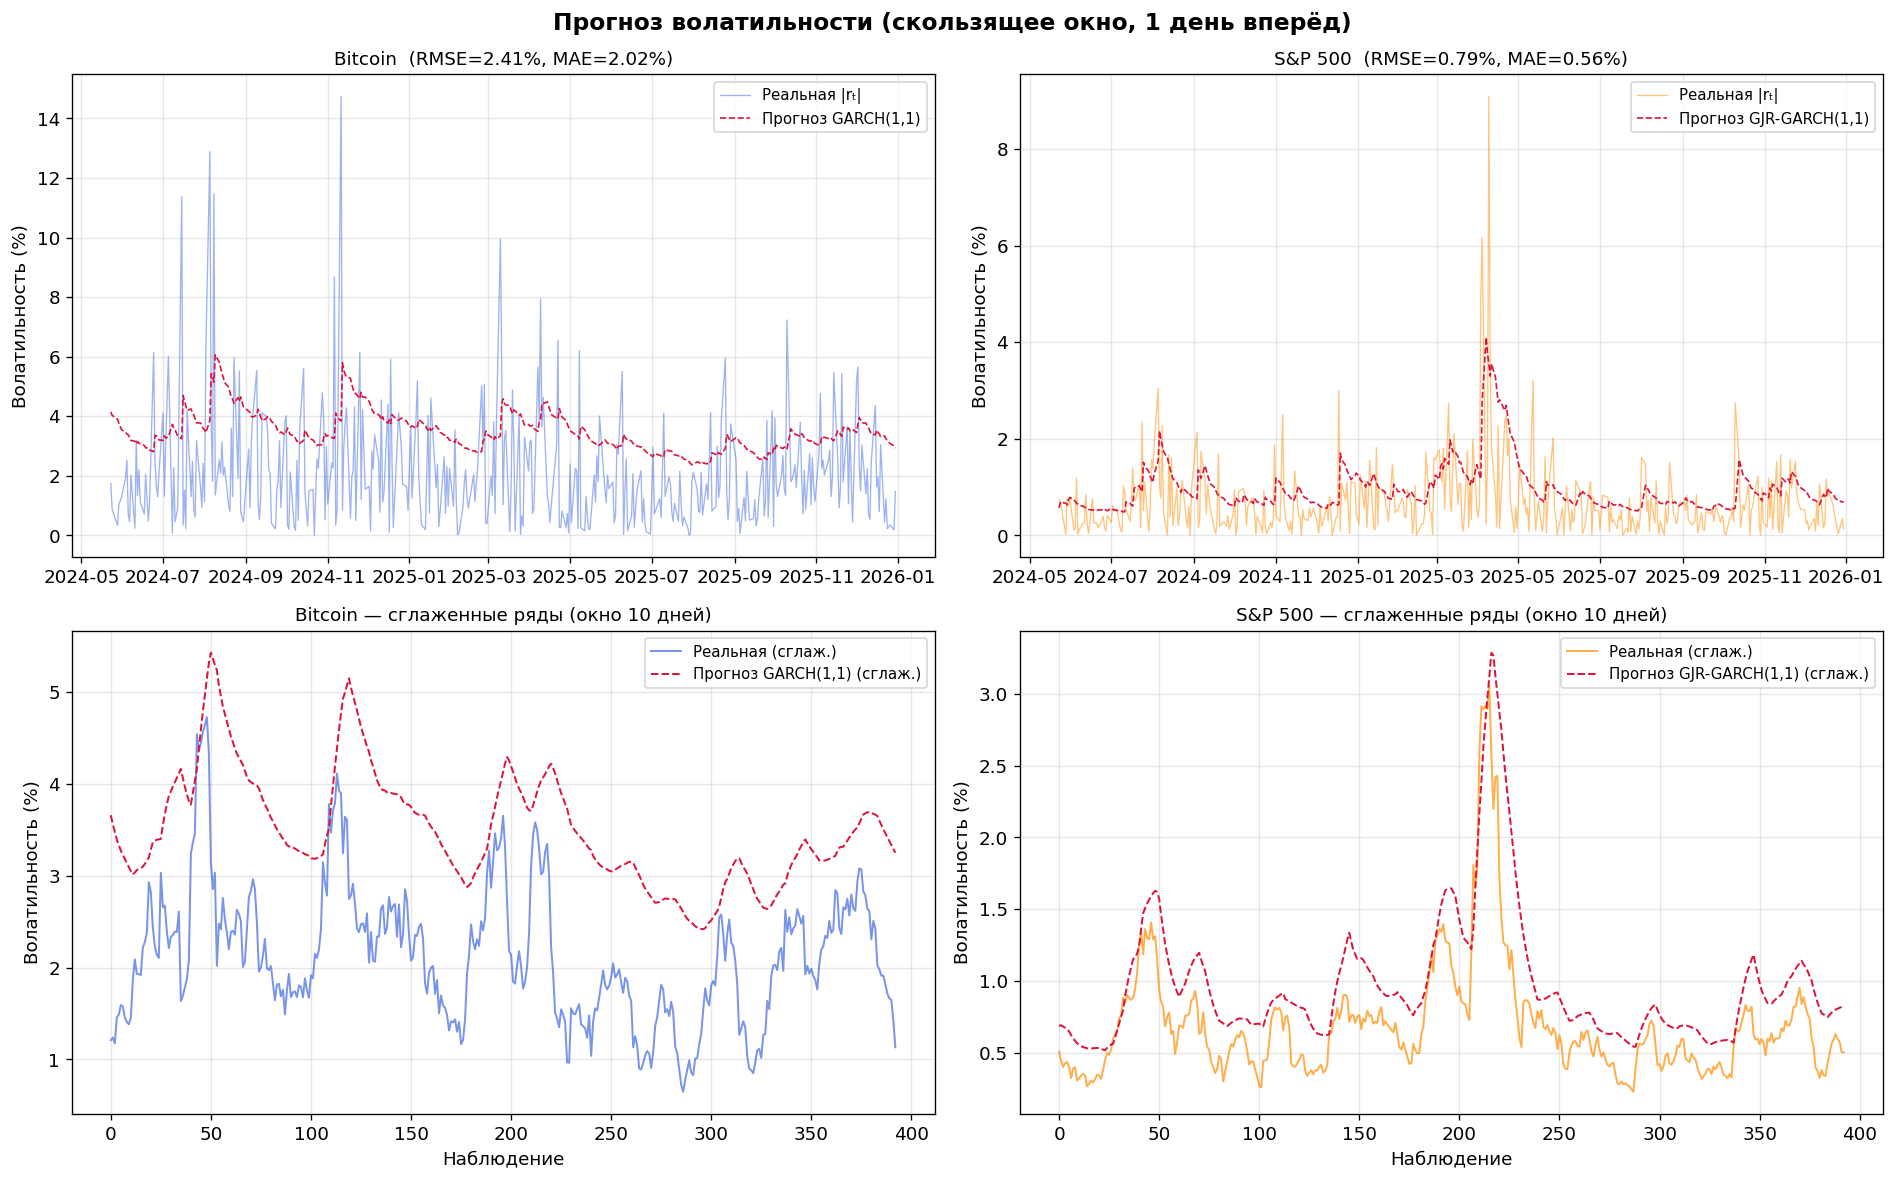

In [51]:
window_smooth = 10

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Прогноз волатильности (скользящее окно, 1 день вперёд)',
             fontsize=14, fontweight='bold')

# Сырые ряды
for ax, fc, act, idx, label, color, model_label in [
        (axes[0,0], fc_btc, act_btc, idx_btc,
         'Bitcoin',  'royalblue', 'GARCH(1,1)'),
        (axes[0,1], fc_sp,  act_sp,  idx_sp,
         'S&P 500', 'darkorange', 'GJR-GARCH(1,1)')]:

    ax.plot(idx, act, color=color, alpha=0.5, linewidth=0.8, label='Реальная |rₜ|')
    ax.plot(idx, fc,  color='crimson', linewidth=1, linestyle='--',
            label=f'Прогноз {model_label}')
    ax.set_title(f'{label}  (RMSE={rmse(act,fc):.2f}%, MAE={mae(act,fc):.2f}%)',
                 fontsize=11)
    ax.set_ylabel('Волатильность (%)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Сглаженные ряды
kernel = np.ones(window_smooth) / window_smooth
for ax, fc, act, label, color, model_label in [
        (axes[1,0], fc_btc, act_btc, 'Bitcoin',  'royalblue', 'GARCH(1,1)'),
        (axes[1,1], fc_sp,  act_sp,  'S&P 500', 'darkorange', 'GJR-GARCH(1,1)')]:

    ax.plot(np.convolve(act, kernel, mode='valid'), color=color,
            alpha=0.7, linewidth=1.2, label='Реальная (сглаж.)')
    ax.plot(np.convolve(fc,  kernel, mode='valid'), color='crimson',
            linewidth=1.2, linestyle='--', label=f'Прогноз {model_label} (сглаж.)')
    ax.set_title(f'{label} — сглаженные ряды (окно {window_smooth} дней)', fontsize=11)
    ax.set_ylabel('Волатильность (%)')
    ax.set_xlabel('Наблюдение')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((np.array(y_true) - np.array(y_pred))**2))

def qlike(actual_abs_pct, forecast_std_pct):
    r2   = np.array(actual_abs_pct) ** 2
    sig2 = np.array(forecast_std_pct) ** 2
    sig2 = np.where(sig2 <= 0, 1e-20, sig2)
    return np.mean(np.log(sig2) + r2 / sig2)

def rolling_forecast_vol_pct(train_series, test_series, p=1, q=1, o=0, dist='t'):
    forecast_list, actual_list = [], []
    expanding = list(train_series.dropna())

    for i in range(len(test_series)):
        series_now = pd.Series(expanding).dropna()
        try:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                fitted = arch_model(series_now, mean='Constant', vol='GARCH',
                                    p=p, q=q, o=o, dist=dist).fit(disp='off')
                fc_var = fitted.forecast(horizon=1).variance.iloc[-1, 0]
                fc_std = np.sqrt(max(fc_var, 0))
        except Exception:
            fc_std = np.nan

        forecast_list.append(fc_std if (not np.isnan(fc_std) and fc_std > 0) else np.nan)
        actual_list.append(abs(test_series.iloc[i]))
        if not np.isnan(test_series.iloc[i]):
            expanding.append(test_series.iloc[i])

    fc_arr  = np.array(forecast_list)
    act_arr = np.array(actual_list)
    mask    = ~np.isnan(fc_arr)
    return fc_arr[mask], act_arr[mask]


model_specs = [
    ('GARCH(1,1)',      1, 1, 0),
    ('GARCH(1,2)',      1, 2, 0),
    ('GARCH(2,1)',      2, 1, 0),
    ('GJR-GARCH(1,1)', 1, 1, 1),
]

print('Метрики out-of-sample прогноза волатильности')
print(f"\n{'Модель':<20} {'RMSE(SP500)':>12} {'QLIKE(SP500)':>13} {'RMSE(BTC)':>11} {'QLIKE(BTC)':>11}")


t8_rows = []
for spec_name, p_ord, q_ord, o_ord in model_specs:
    print(f"  Считаю {spec_name}...", end='\r')
    fc_sp, act_sp = rolling_forecast_vol_pct(sp500_train * 100, sp500_test * 100, p=p_ord, q=q_ord, o=o_ord)
    fc_bt, act_bt = rolling_forecast_vol_pct(btc_train   * 100, btc_test   * 100, p=p_ord, q=q_ord, o=o_ord)

    r_sp, q_sp = rmse(act_sp, fc_sp), qlike(act_sp, fc_sp)
    r_bt, q_bt = rmse(act_bt, fc_bt), qlike(act_bt, fc_bt)

    marker = '*' if spec_name in ('GJR-GARCH(1,1)',) else ' '
    print(f"  {spec_name:<20} {r_sp:>11.3f} {q_sp:>13.3f} {r_bt:>11.3f} {q_bt:>11.3f} {marker}")
    t8_rows.append({'model': spec_name, 'rmse_sp': r_sp, 'qlike_sp': q_sp, 'rmse_bt': r_bt, 'qlike_bt': q_bt})

best_rmse_sp  = min(t8_rows, key=lambda x: x['rmse_sp'])['model']
best_qlike_sp = min(t8_rows, key=lambda x: x['qlike_sp'])['model']
best_rmse_bt  = min(t8_rows, key=lambda x: x['rmse_bt'])['model']
best_qlike_bt = min(t8_rows, key=lambda x: x['qlike_bt'])['model']
print(f"\n* Лучшая по RMSE:   S&P 500 {best_rmse_sp},  Bitcoin {best_rmse_bt}")
print(f"* Лучшая по QLIKE:  S&P 500 {best_qlike_sp},  Bitcoin → {best_qlike_bt}")

Таблица 8 — Метрики out-of-sample прогноза волатильности

Модель                RMSE(SP500)  QLIKE(SP500)   RMSE(BTC)  QLIKE(BTC)
----------------------------------------------------------------------
  GARCH(1,1)                 0.839         0.785       2.412       3.142  
  GARCH(1,2)                 0.839         0.785       2.411       3.141  
  GARCH(2,1)                 0.843         0.789       2.412       3.142  
  GJR-GARCH(1,1)             0.795         0.710       2.416       3.144 *
----------------------------------------------------------------------

* Лучшая по RMSE:   S&P 500 GJR-GARCH(1,1),  Bitcoin GARCH(1,2)
* Лучшая по QLIKE:  S&P 500 GJR-GARCH(1,1),  Bitcoin → GARCH(1,2)


In [ ]:
from scipy.stats import chi2 as chi2_dist

# считаем var на обучающей выборке (in-sample) для проверки
def calculate_var(fitted_model, returns_series, confidence_levels=(0.95, 0.99)):
    cond_vol = fitted_model.conditional_volatility
    mu = fitted_model.params.get('mu', 0)
    nu = fitted_model.params.get('nu', 5)

    var_df = pd.DataFrame(index=returns_series.index)
    var_df['return'] = returns_series

    for cl in confidence_levels:
        q = stats.t.ppf(1 - cl, df=nu)
        var_df[f'VaR_{int(cl*100)}'] = mu + q * cond_vol

    return var_df

var_btc   = calculate_var(btc_models['GARCH(1,1)'],       btc_train)
var_sp500 = calculate_var(sp500_models['GJR-GARCH(1,1)'], sp500_train)
print(f"VaR рассчитан: BTC {var_btc.shape}, SP500 {var_sp500.shape}")


def kupiec_test(returns_series, var_series, confidence_level):
    alpha = 1 - confidence_level
    ret, var = returns_series.dropna().align(var_series.dropna(), join='inner')
    T = len(ret)
    V = int((ret < var).sum())
    p_hat = V / T if T > 0 else 0

    if V in (0, T):
        lr_pof, p_val = np.nan, np.nan
    else:
        ll0 = V * np.log(alpha)       + (T - V) * np.log(1 - alpha)
        ll1 = V * np.log(p_hat)       + (T - V) * np.log(1 - p_hat)
        lr_pof = -2 * (ll0 - ll1)
        p_val  = 1 - chi2_dist.cdf(lr_pof, df=1)

    return {
        'T': T, 'V': V,
        'exp_V': round(alpha * T, 1),
        'freq':  round(p_hat * 100, 2),
        'LR_POF': round(lr_pof, 3) if not np.isnan(lr_pof) else 'n/a',
        'p_val': p_val
    }


def rolling_var_forecast(train_series, test_series,
                         use_gjr=False, confidence_levels=(0.95, 0.99)):
    var_records = {cl: [] for cl in confidence_levels}
    ret_list = []

    for i in range(len(test_series)):
        window = (pd.concat([train_series, test_series.iloc[:i]])
                  if i > 0 else train_series)
        window_pct = window.dropna() * 100

        try:
            kwargs = {'p': 1, 'q': 1, 'o': 1} if use_gjr else {'p': 1, 'q': 1}
            fit = arch_model(
                window_pct, mean='Constant', vol='GARCH', dist='t', **kwargs
            ).fit(update_freq=0, disp='off')

            sigma = np.sqrt(fit.forecast(horizon=1).variance.iloc[-1, 0])
            mu_f  = fit.params.get('mu', 0)
            nu_f  = fit.params.get('nu', 5)

            for cl in confidence_levels:
                q = stats.t.ppf(1 - cl, df=nu_f)
                var_records[cl].append(mu_f + q * sigma)

        except Exception:
            for cl in confidence_levels:
                var_records[cl].append(np.nan)

        ret_list.append(test_series.iloc[i] * 100)

    df = pd.DataFrame({'return': ret_list}, index=test_series.index)
    for cl in confidence_levels:
        df[f'VaR_{cl}'] = var_records[cl]
    return df.dropna()


print("Считаем VaR тестовой выборки")

var_test_sp = rolling_var_forecast(sp500_train, sp500_test, use_gjr=True)
print(f"  готово: {len(var_test_sp)}/{len(sp500_test)}")

var_test_bt = rolling_var_forecast(btc_train, btc_test, use_gjr=False)
print(f"  готово: {len(var_test_bt)}/{len(btc_test)}")


# таблица 9
print("\nБэктестирование VaR (тестовая выборка)")
print(f"{'Актив':<10} {'Ур-нь':>6} {'T':>5} {'Ожид.':>7} {'Факт.':>7} "
      f"{'Доля%':>7} {'LR_POF':>8} {'p-зн.':>8} {'Вывод':>12}")


for label, var_df in [('S&P 500', var_test_sp), ('Bitcoin', var_test_bt)]:
    for cl in [0.95, 0.99]:
        res     = kupiec_test(var_df['return'], var_df[f'VaR_{cl}'], cl)
        verdict = 'OK' if isinstance(res['p_val'], float) and res['p_val'] > 0.05 else 'Откл.'
        p_str   = f"{res['p_val']:.3f}" if isinstance(res['p_val'], float) else 'n/a'
        print(f"{label:<10} {int(cl*100):>5}%  {res['T']:>5} {res['exp_V']:>7} "
              f"{res['V']:>7} {res['freq']:>6}% {str(res['LR_POF']):>8} "
              f"{p_str:>8} {verdict:>12}")

print("H0: доля нарушений = теоретической. p>0.05 — модель адекватна.")

VaR рассчитан: BTC (1608, 3), SP500 (1608, 3)
Считаем VaR тестовой выборки
  готово: 402/402
  готово: 402/402

ТАБЛИЦА 9 — Бэктестирование VaR (тестовая выборка)
Актив       Ур-нь     T   Ожид.   Факт.   Доля%   LR_POF    p-зн.        Вывод
--------------------------------------------------------------------------------
S&P 500       95%    402    20.1      16   3.98%    0.944    0.331         ✓ OK
S&P 500       99%    402     4.0       3   0.75%    0.287    0.592         ✓ OK
Bitcoin       95%    402    20.1       3   0.75%   23.542    0.000      ✗ Откл.
Bitcoin       99%    402     4.0       0    0.0%      n/a      nan      ✗ Откл.
--------------------------------------------------------------------------------
H0: доля нарушений = теоретической. p>0.05 — модель адекватна.


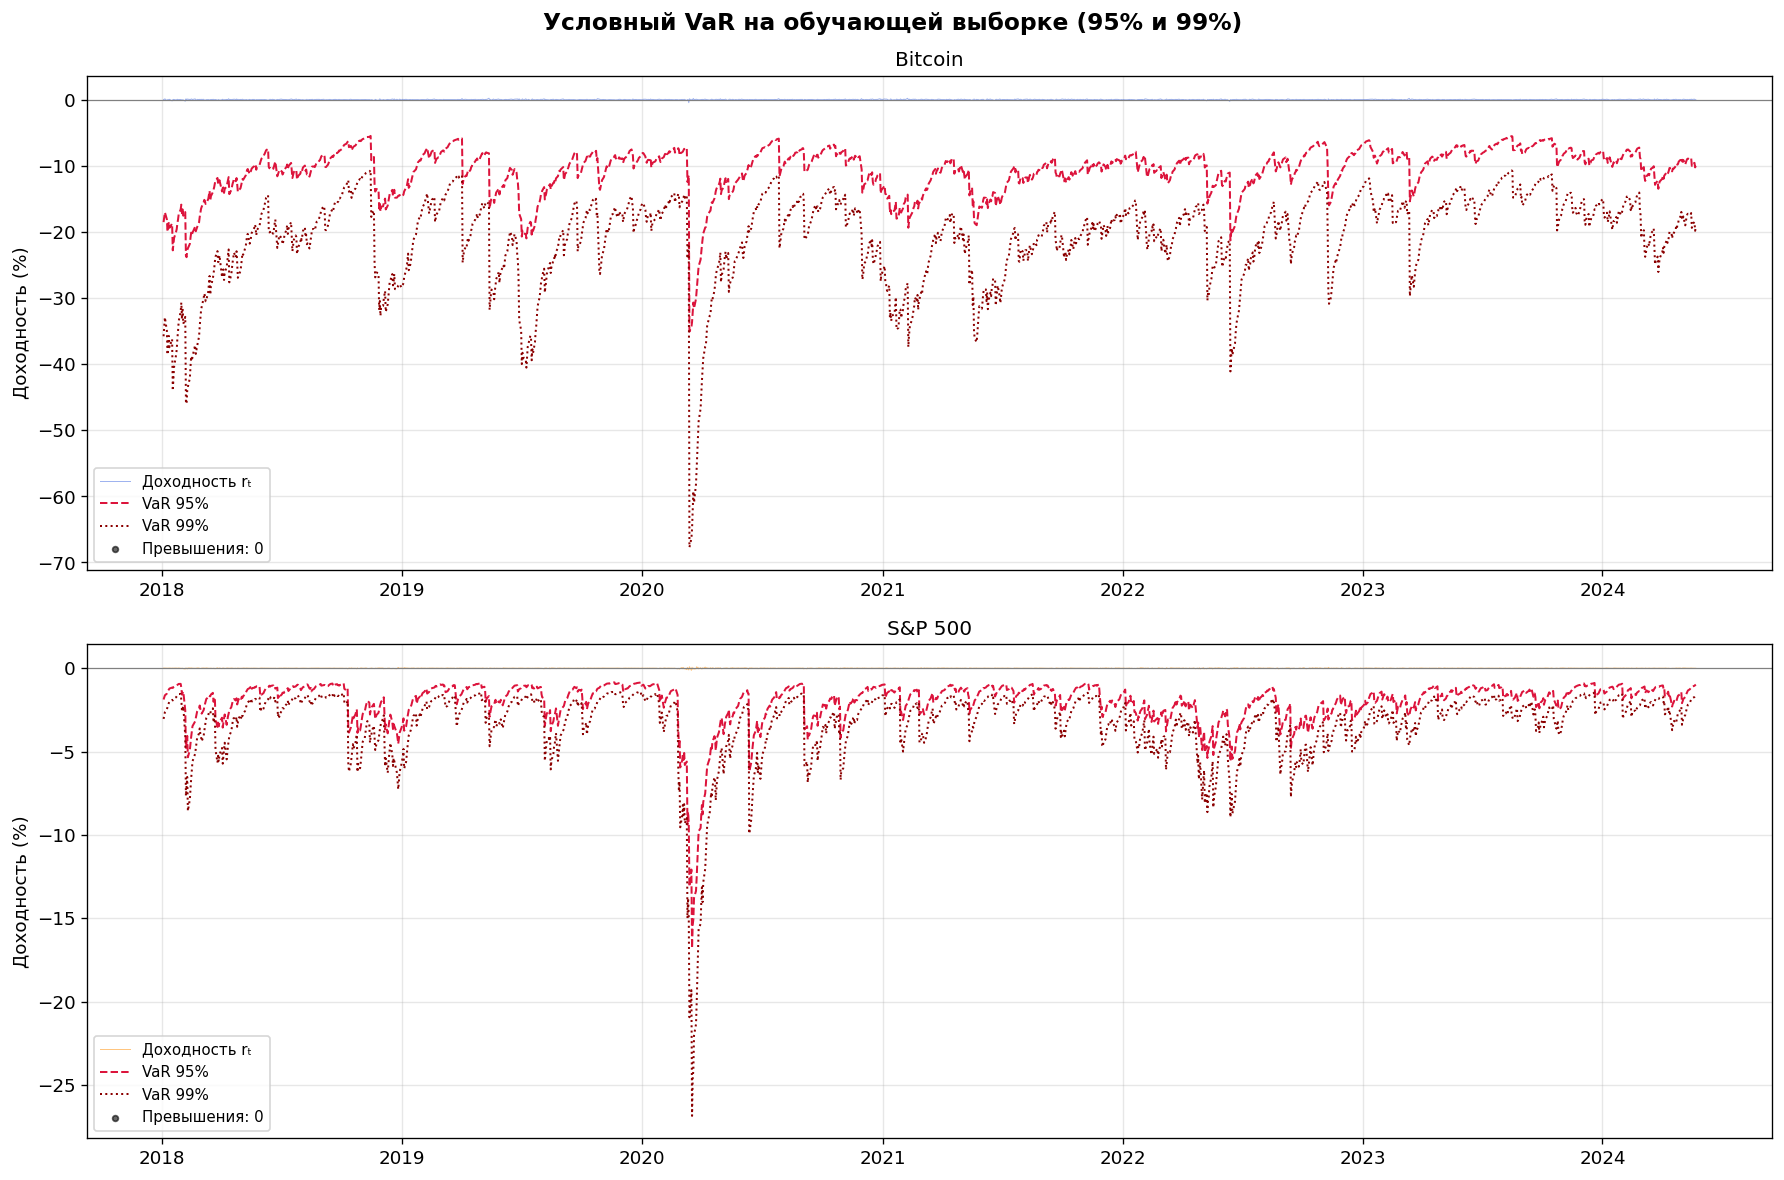

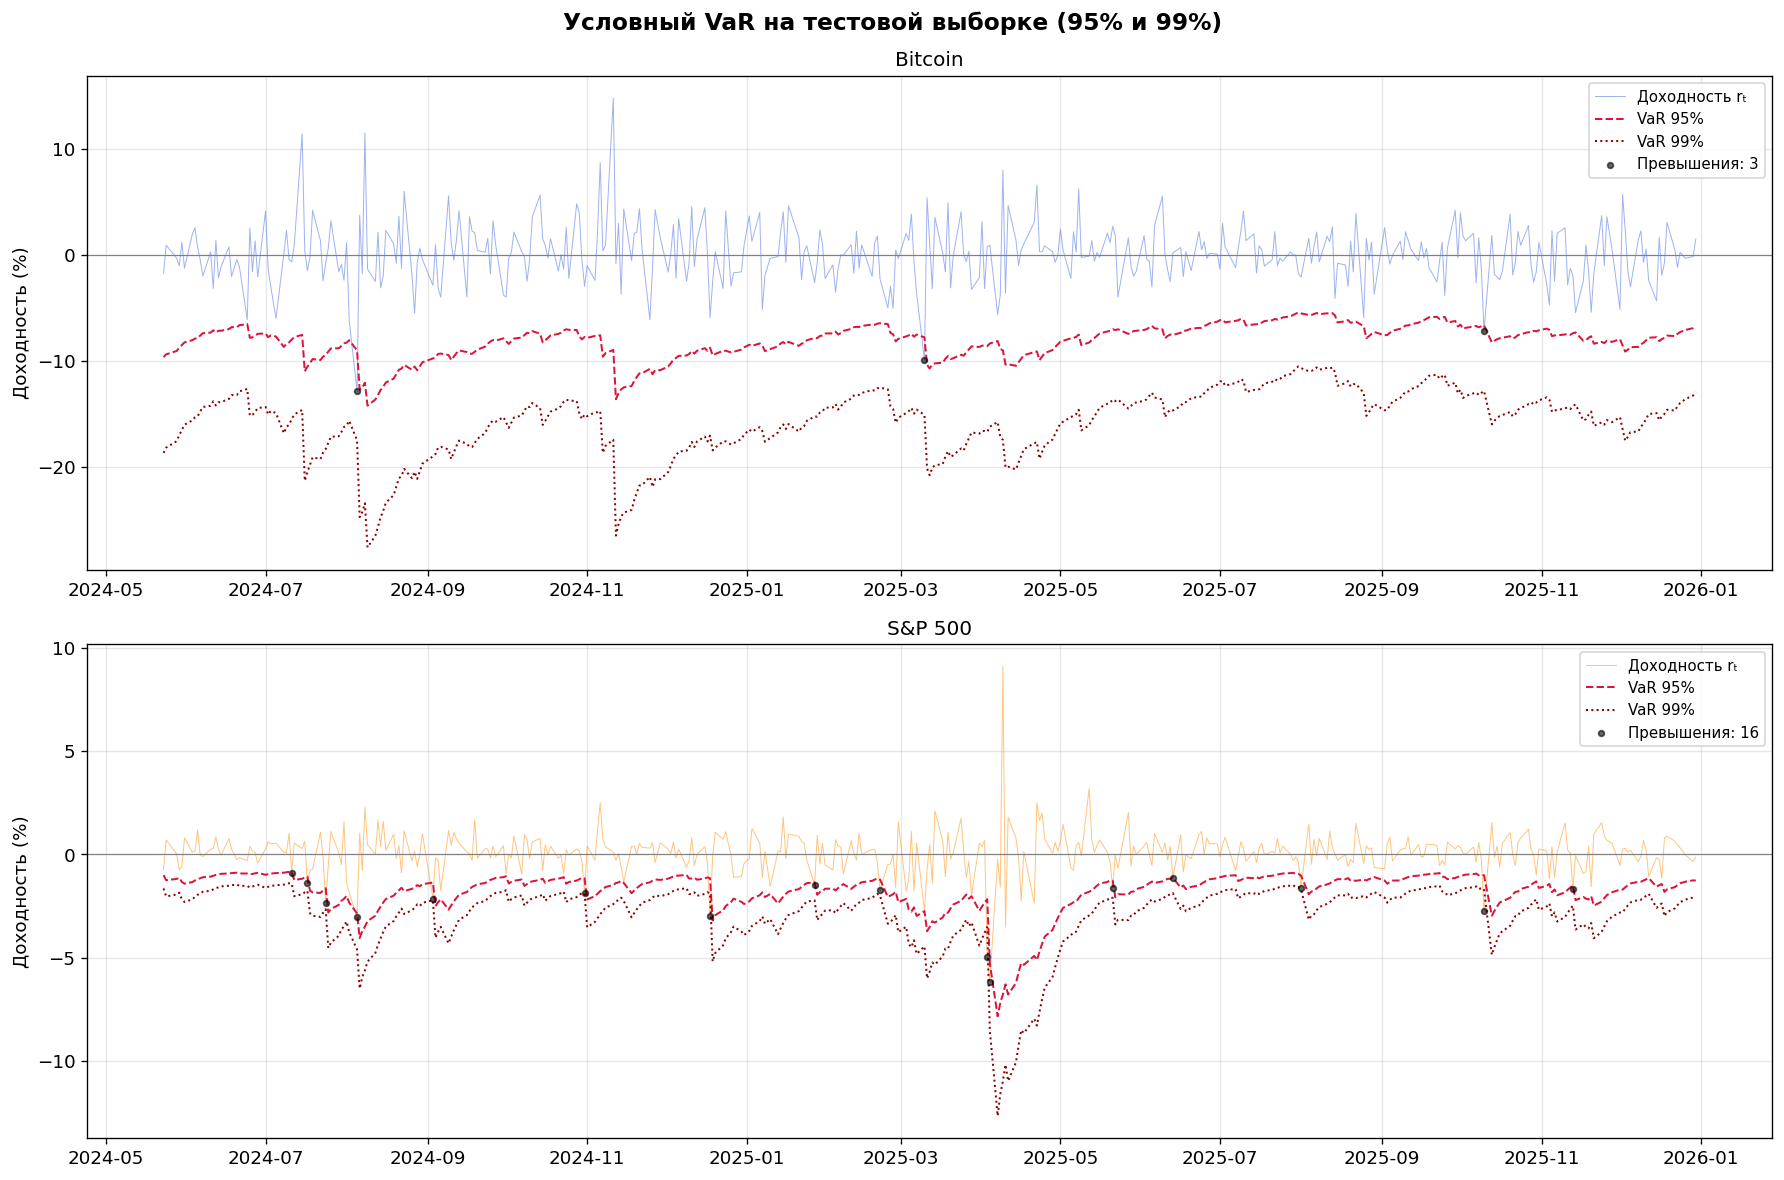

In [54]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))
fig.suptitle('Условный VaR на обучающей выборке (95% и 99%)',
             fontsize=14, fontweight='bold')

for ax, var_df, color, label in [
    (axes[0], var_btc,   'royalblue',  'Bitcoin'),
    (axes[1], var_sp500, 'darkorange', 'S&P 500'),
]:
    ax.plot(var_df.index, var_df['return'],
            color=color, alpha=0.5, linewidth=0.6, label='Доходность rₜ')
    ax.plot(var_df.index, var_df['VaR_95'],
            color='crimson', linewidth=1.2, linestyle='--', label='VaR 95%')
    ax.plot(var_df.index, var_df['VaR_99'],
            color='darkred', linewidth=1.2, linestyle=':', label='VaR 99%')
    breaches = var_df[var_df['return'] < var_df['VaR_95']]
    ax.scatter(breaches.index, breaches['return'],
               color='black', s=12, zorder=5, label=f'Превышения: {len(breaches)}', alpha=0.6)
    ax.axhline(0, color='grey', linewidth=0.7)
    ax.set_title(label, fontsize=12)
    ax.set_ylabel('Доходность (%)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(2, 1, figsize=(15, 10))
fig.suptitle('Условный VaR на тестовой выборке (95% и 99%)',
             fontsize=14, fontweight='bold')

for ax, var_df, color, label in [
    (axes[0], var_test_bt, 'royalblue',  'Bitcoin'),
    (axes[1], var_test_sp, 'darkorange', 'S&P 500'),
]:
    ax.plot(var_df.index, var_df['return'],
            color=color, alpha=0.5, linewidth=0.6, label='Доходность rₜ')
    ax.plot(var_df.index, var_df['VaR_0.95'],   # <- ключи float
            color='crimson', linewidth=1.2, linestyle='--', label='VaR 95%')
    ax.plot(var_df.index, var_df['VaR_0.99'],
            color='darkred', linewidth=1.2, linestyle=':', label='VaR 99%')
    breaches = var_df[var_df['return'] < var_df['VaR_0.95']]
    ax.scatter(breaches.index, breaches['return'],
               color='black', s=12, zorder=5, label=f'Превышения: {len(breaches)}', alpha=0.6)
    ax.axhline(0, color='grey', linewidth=0.7)
    ax.set_title(label, fontsize=12)
    ax.set_ylabel('Доходность (%)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

КОРРЕЛЯЦИЯ ДОХОДНОСТЕЙ BTC-USD и ^GSPC
  Весь период:           0.2972 (p-value = 3.0692e-42)
  Обучающая выборка:     0.2820
  Тестовая выборка:      0.4170


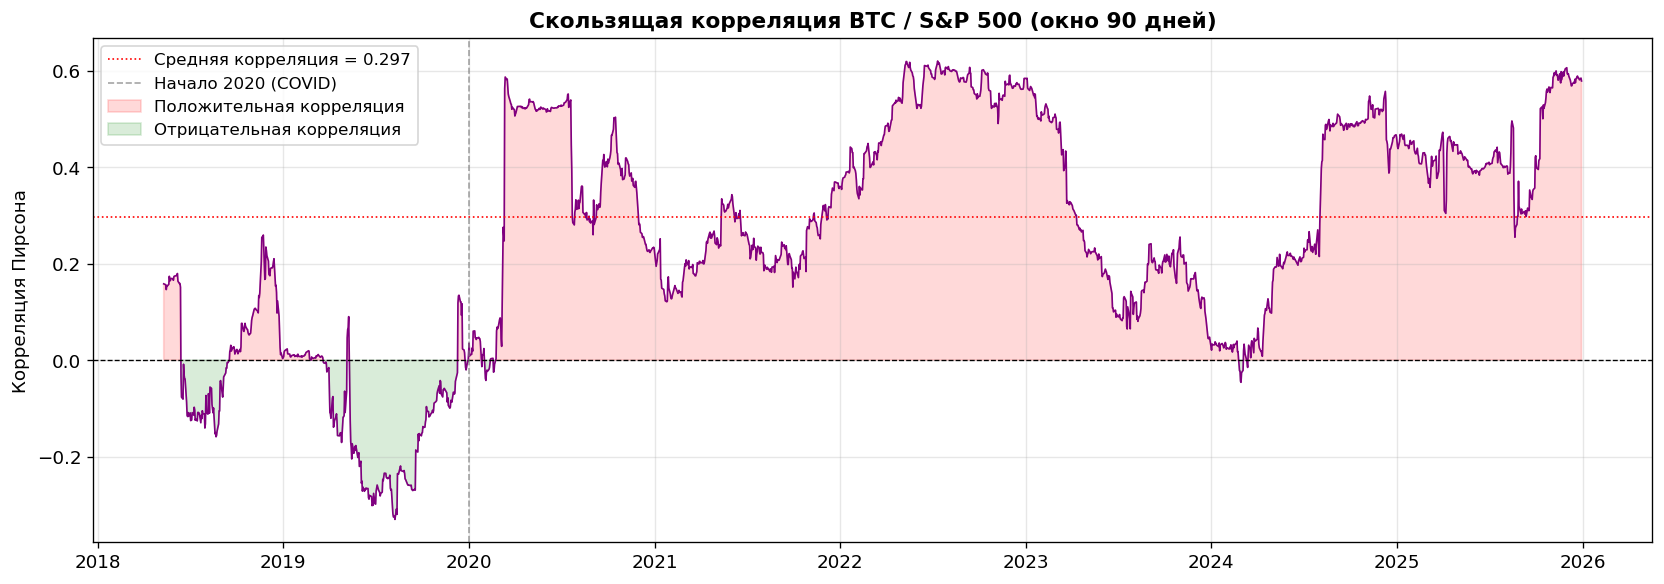


Характеристики скользящей 90-дневной корреляции S&P 500 / Bitcoin
  Характеристика                    2018–2019      2020–2025
  Медиана                              -0.066          0.369
  Максимум                              0.259          0.620
  Минимум                              -0.330         -0.046
  Ст. откл.                             0.139          0.174
  Статическая корреляция (весь период): 0.2972
  Наблюдений в скользящей корреляции: ранний период = 413, поздний = 1507


In [57]:
from scipy.stats import pearsonr
# Расчет с p-value
corr_full, p_value = pearsonr(returns['BTC-USD'].dropna(), returns['^GSPC'].dropna())
corr_train = btc_train.corr(sp500_train)
corr_test = btc_test.corr(sp500_test)

print("КОРРЕЛЯЦИЯ ДОХОДНОСТЕЙ BTC-USD и ^GSPC")
print(f"  Весь период:           {corr_full:.4f} (p-value = {p_value:.4e})")
print(f"  Обучающая выборка:     {corr_train:.4f}")
print(f"  Тестовая выборка:      {corr_test:.4f}")

rolling_window = 90
rolling_corr = returns['BTC-USD'].rolling(rolling_window).corr(returns['^GSPC'])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(rolling_corr, color='purple', linewidth=1)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axhline(corr_full, color='red', linewidth=1,
           linestyle=':', label=f'Средняя корреляция = {corr_full:.3f}')
ax.axvline(pd.Timestamp('2020-01-01'), color='grey', linewidth=1,
           linestyle='--', alpha=0.7, label='Начало 2020 (COVID)')
ax.fill_between(rolling_corr.index, rolling_corr, 0,
                where=rolling_corr > 0, alpha=0.15, color='red', label='Положительная корреляция')
ax.fill_between(rolling_corr.index, rolling_corr, 0,
                where=rolling_corr < 0, alpha=0.15, color='green', label='Отрицательная корреляция')
ax.set_title(f'Скользящая корреляция BTC / S&P 500 (окно {rolling_window} дней)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Корреляция Пирсона')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

rolling_corr_90 = rolling_corr.dropna()

# Разбивка на периоды
mask_early = rolling_corr_90.index < '2020-01-01'
mask_late  = rolling_corr_90.index >= '2020-01-01'

rc_early = rolling_corr_90[mask_early]
rc_late  = rolling_corr_90[mask_late]

print("\nХарактеристики скользящей 90-дневной корреляции S&P 500 / Bitcoin")
print(f"  {'Характеристика':<28} {'2018–2019':>14} {'2020–2025':>14}")


stats_rows = [
    ('Медиана', rc_early.median(), rc_late.median()),
    ('Максимум', rc_early.max(), rc_late.max()),
    ('Минимум', rc_early.min(), rc_late.min()),
    ('Ст. откл.', rc_early.std(), rc_late.std()),
]

for label, v_early, v_late in stats_rows:
    print(f"  {label:<28} {v_early:>14.3f} {v_late:>14.3f}")

print(f"  Статическая корреляция (весь период): {corr_full:.4f}")
print(f"  Наблюдений в скользящей корреляции: ранний период = {len(rc_early)}, поздний = {len(rc_late)}")